In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.stats import uniform
from astropy.visualization import hist
from sklearn.neighbors import KernelDensity
from scipy.stats import ks_2samp
from scipy import integrate


%config InlineBackend.figure_format='retina'
plt.rc('text', usetex=True)

## Time to get your hands dirty! The irreducible mass of black holes.


Working with samples is often easier than working with the function form of the pdf (but then the density must be reconstructed numerically!)


This example comes straight out of my research in general relativity.

Consider a rotating black hole. In [1969](https://ui.adsabs.harvard.edu/abs/1969NCimR...1..252P/abstract), Roger Penrose (now [Nobel Prize in Physics](https://www.nobelprize.org/prizes/physics/2020/penrose/facts/) for the theory of black holes) discovered that one can extract energy from a rotating black hole:


A rotating black-hole has a region called ergosphere such that infalling particles have negative energy. Penrose imagined a particle that enters that region and decays: half will fall in and half will escape to infinity, carring some energy with it. In a nutshell, we've extracted energy=mass from a black hole! It turns out that one also has to extract angular momentum, not just energy. But angular momentum runs out first, such that a repeated series of Penrose processes leaves behind a non-rotating BH with a remnant mass which is called "irreducible". 

For a BH of mass $M$ spin $\chi\in [0,1]$, the irreducible mass is 
$$
M_{\rm irr} =
 M \sqrt{\frac{1+\sqrt{1-\chi^2}}{2}}
$$
For convenience, let us define 

$$f(\chi) = \frac{M_{\rm irr}}{M}= \sqrt{\frac{1+\sqrt{1-\chi^2}}{2}}$$

Suppose you have repeated measurments of $M$ and $\chi$. This is just because we're still frequentists for now. When we will put our Bayesian hat on, these distributions will be the *posterior samples* from a single measurement.

Let's assume that

- the spin $\chi$ is uniformly distributed between 0 and 1.
- the mass $M$ is normally distributed with mean $\mu$ and standard deviation $\sigma$.
- (masses and spins are uncorrelated)

These are simplistic assumption that, however, are not too far from what we are now measuring with gravitational-wave detectors. It's a toy model, but not a totally unreasonable one.

**Tasks**:

1. Start with a value of $\sigma=0.02$. Note that $\mu$ is a scale and not a parameter: you can normalize all quantities with a dimension of mass by $\mu$. Just set $\mu=1$ in your code and remember that all masses in the problem are measured in units of $\mu$. 


In [2]:
N = 1000

Chi = uniform.rvs(size = N)

mu = 1.
sigma = 0.02
M = norm(mu, sigma).rvs(N)

In [3]:
Mirr = M*np.sqrt((1+np.sqrt(1-Chi**2))/2)
f = np.sqrt((1+np.sqrt(1-Chi**2))/2)


2. Plot the resulting pdf of $M_{\rm irr}$. First try an histogram with one the rules of thumb we've seen above.

*Hint (for point 2)*: You don't know the functional form of the pdf of $M_{\rm irr}$... but you don't need it if you just want to generate samples! That's the nice thing about numerics!


Text(0.5, 0, 'Irreducible mass/$\\mu$')

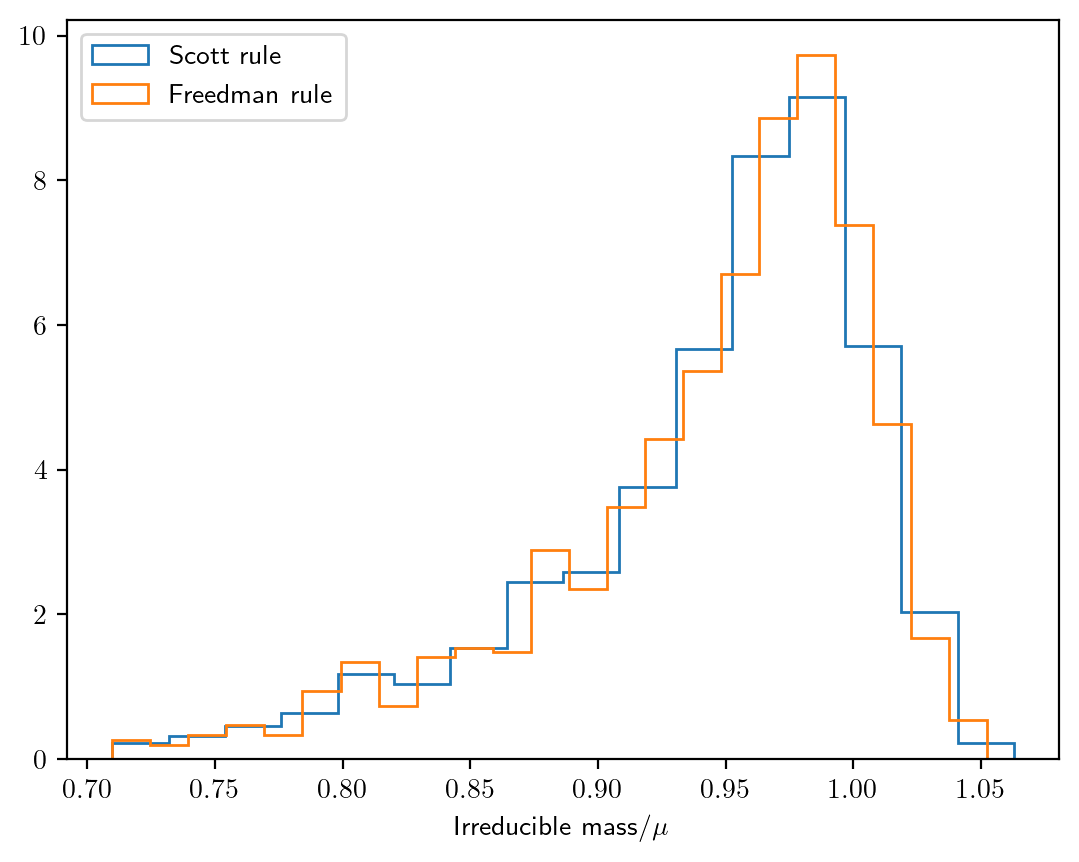

In [4]:
# bin_width = 3.5*sigma/N**(1./3.) Scott
# bin_width = 2.7*sigmaG/N**(1./3.) Freedman
_ = hist(Mirr, bins = 'scott', histtype='step', density = True, label = 'Scott rule')
_ = hist(Mirr, bins = 'freedman', histtype = 'step', density = True, label = 'Freedman rule')
plt.legend()
plt.xlabel(r'Irreducible mass/$\mu$')


3. Using the same samples, plot the distribution of $M_{\rm irr}$ using a KDE.


In [5]:
Mirr_sk = Mirr[:,np.newaxis]
Mgrid = np.linspace(Mirr.min(), Mirr.max(), 1000)
Mgrid_sk = Mgrid[:,np.newaxis]

kde = KernelDensity(bandwidth=0.01, kernel = 'gaussian')
kde_fit = kde.fit(Mirr_sk)
kde_pdf = np.exp(kde.score_samples(Mgrid_sk))

Text(0.5, 0, 'Irreducible mass/$\\mu$')

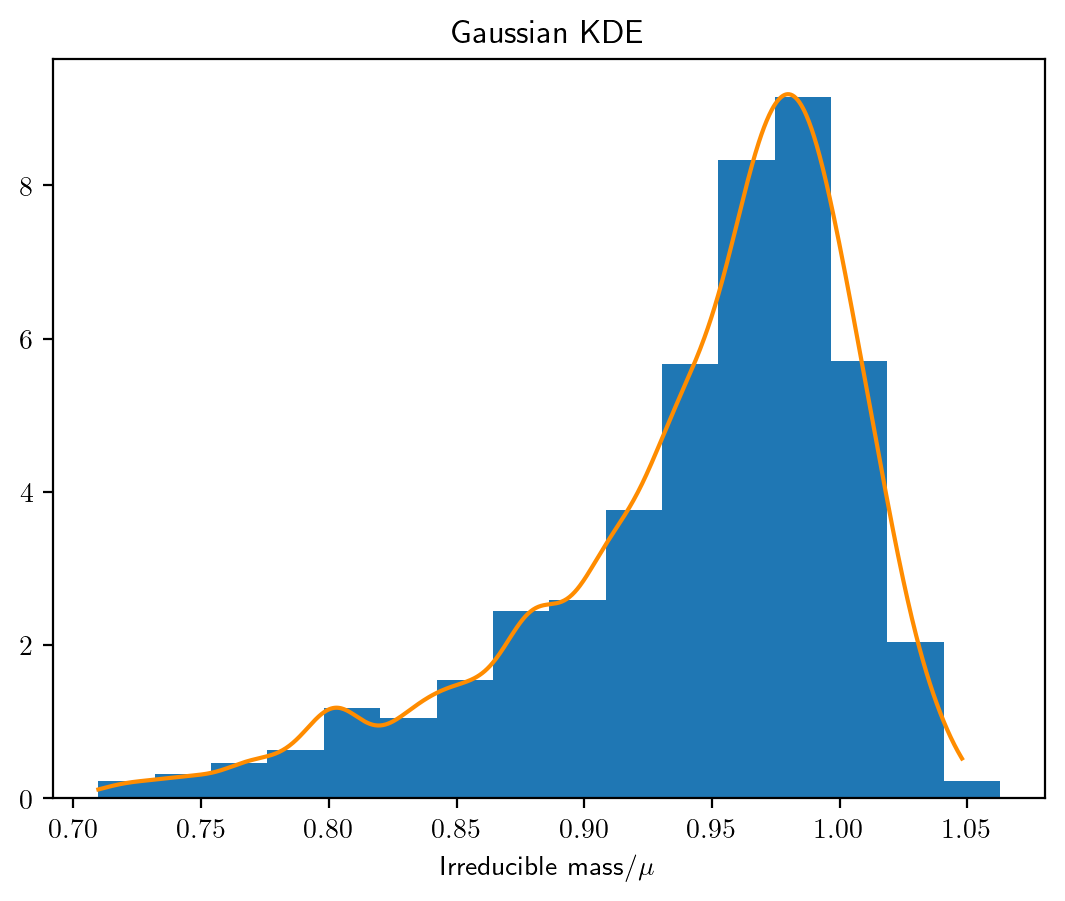

In [6]:
_ = hist(Mirr, bins = 'scott', density = True)
plt.plot(Mgrid, kde_pdf, c = 'darkorange')
plt.title('Gaussian KDE')
plt.xlabel(r'Irreducible mass/$\mu$')


4. Compute the KS distance between ${M_{\rm irr}}/\mu$ and ${f}$ as a function of $\sigma$. Discuss the limits at large and small values of $\sigma$. 

5. Compute the KS distance between ${M_{\rm irr}}$ and $M$ as a function of $\sigma$. Discuss the limits at large and small values of $\sigma$.

*Hint (for points 4 and 5)*. This is a KS test between two sets for samples, `scipy.stats.ks_2samp`.


6. You should find that (i) $M_{\rm irr}$ is distributed like $f$ if ${\sigma}\ll \mu$ and (ii) $M_{\rm irr}$ is distributed like $M$ if  $\sigma\gg \mu$.

In [7]:
def ks_Mirr_f(sigma):
    mu = 1.
    N = 1000
    Mass = norm(mu, sigma).rvs(N)
    chi = uniform.rvs(size = N)
    Mirr_sort = (Mass*np.sqrt((1+np.sqrt(1-chi**2))/2))/mu
    f_sort = (np.sqrt((1+np.sqrt(1-chi**2))/2))
    return ks_2samp(Mirr_sort, f_sort)[0]

def ks_Mirr_M(sigma):
    mu = 1.
    N = 1000
    Mass = norm(mu, sigma).rvs(N)
    chi = uniform.rvs(size = N)
    Mirr_sort = (Mass*np.sqrt((1+np.sqrt(1-chi**2))/2))/mu
    return ks_2samp(Mirr_sort, Mass)[0]

In [8]:
ks_f = np.zeros(20)
ks_M = np.zeros(20)

sig= np.logspace(-5,5,20)

for i,s in enumerate(sig):
    ks_f[i] = ks_Mirr_f(s)
    ks_M[i] = ks_Mirr_M(s)


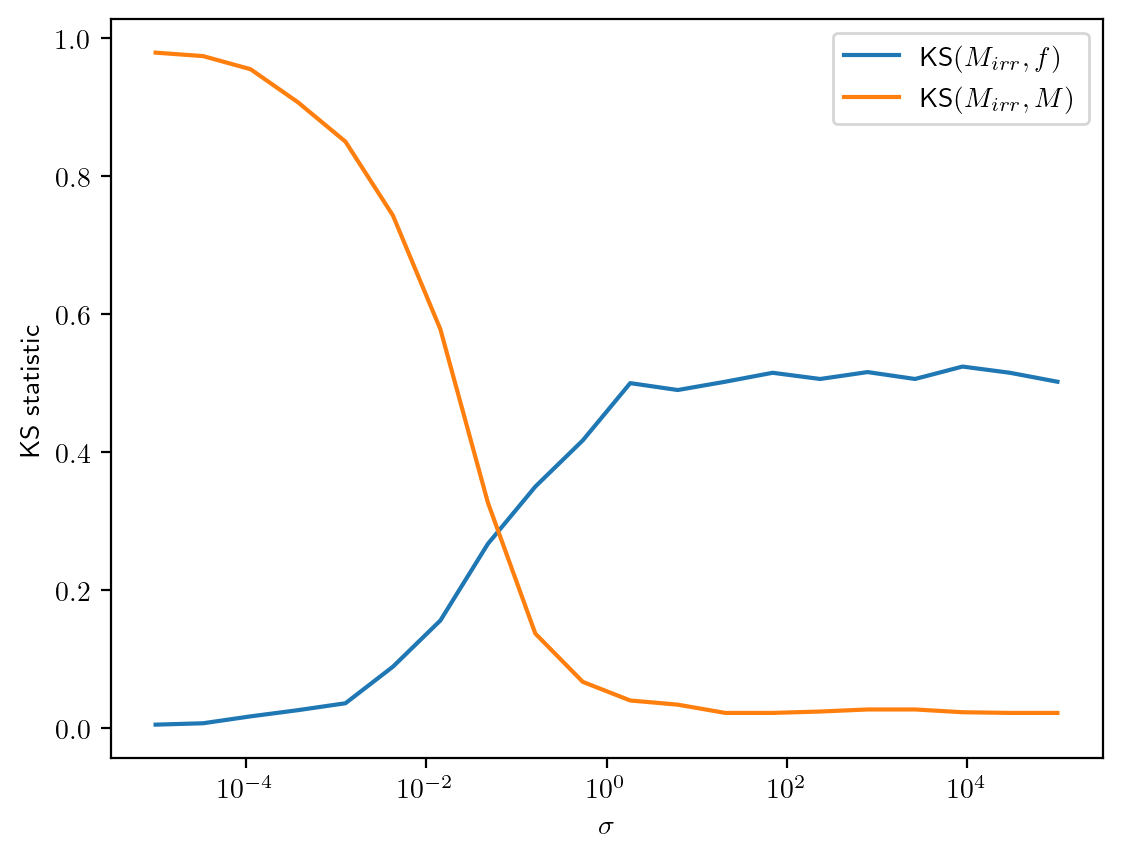

In [9]:
plt.plot(sig, ks_f, label = r'KS$(M_{irr},f)$')
plt.plot(sig, ks_M, label = r'KS$(M_{irr},M)$')
plt.xscale('log')
plt.ylabel('KS statistic')
plt.xlabel(r'$\sigma$')
plt.legend()



7.  Compute the pdf of $f$ from its mathematical definition (pen and paper!). Verify this result: 

\begin{equation}
\pi(f) = 2\frac{2 f^2-1}{\sqrt{1 - f^2}}\,.
\end{equation}

8.  Compute the pdfs of $M_{\rm irr}$ from its mathematical definition (pen and paper!). Verify this result:

$$
p(M_{\rm irr})  = \frac{\sqrt{2/\pi}}{\sigma} \int_{1/\sqrt{2}}^1 \exp\left[{-\frac{(M_{\rm irr}/f -\mu)^2}{2\sigma^2}}\right]  \frac{2 f^2-1}{f \sqrt{1 - f^2}}  \,\, {\rm d}f
$$

The this expression is only semi-analytic; that integral should then be solved numerically.

*Point 7 and point 8 are **not examinable**; those are interesting calculations but you can just assume those expressions and move on with point 9 if you want.*

*Hint (for point 8)*: You want to use [this theorem](https://en.wikipedia.org/wiki/Distribution_of_the_product_of_two_random_variables) for the product of two random variables. 



9. Using the expressions from point 7 and 8, plot those pdfs check that they agree with your KDE reconstructions.


In [10]:
pi = lambda f: 2*(2*f**2-1)/np.sqrt(1-f**2)

f_sk = f[:,np.newaxis]
fgrid = np.linspace(f.min(), f.max(), 1000)
fgrid_sk = fgrid[:,np.newaxis]

kde_f = KernelDensity(bandwidth=0.01, kernel = 'gaussian')
kde_fit_f = kde_f.fit(f_sk)
kde_pdf_f = np.exp(kde_f.score_samples(fgrid_sk))

In [11]:
pi(fgrid.max())

np.float64(26964.60500626833)

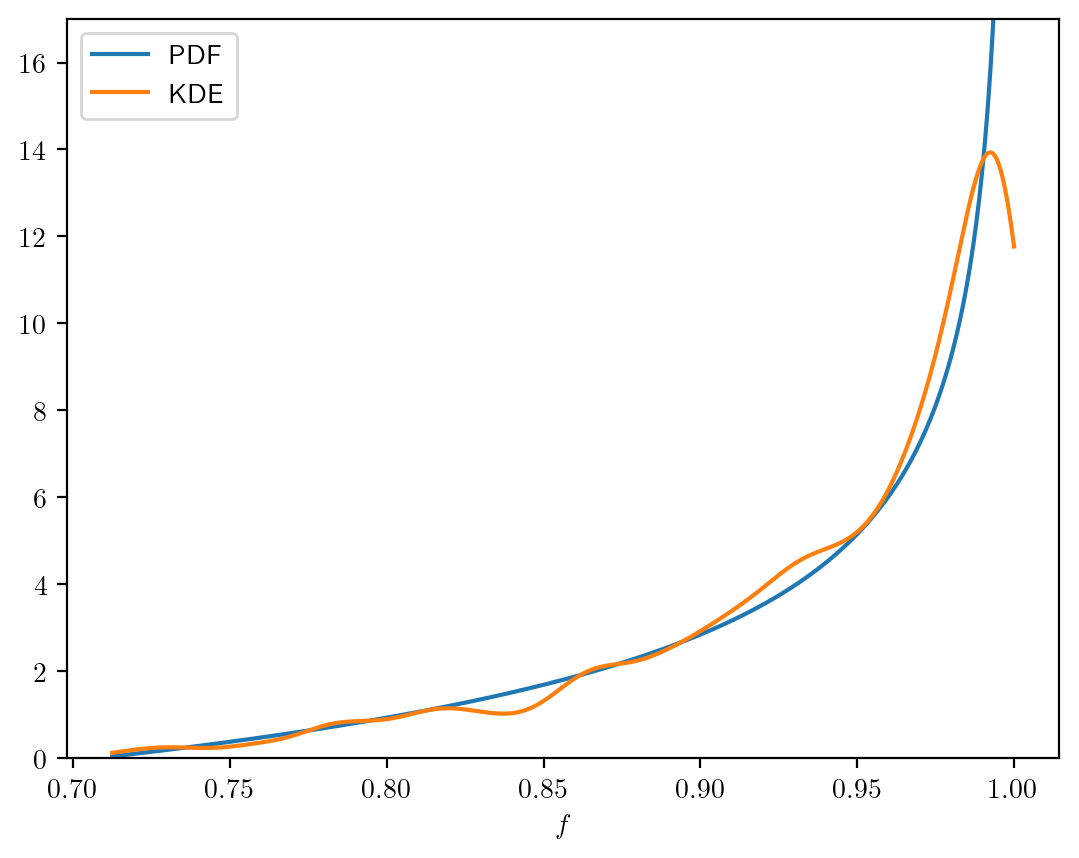

In [12]:
plt.plot(fgrid, pi(fgrid), label = 'PDF')
plt.plot(fgrid, kde_pdf_f, label = 'KDE')
plt.ylim(0,17)
plt.xlabel(r'$f$')
plt.legend()

In [13]:
sigma = 0.02
mu = 1

def int_fun(fval,mirr):
    expon = - (mirr/fval-mu)**2/(2*sigma**2)
    integr = np.exp(expon) * (2*fval**2-1)/(fval*np.sqrt(1-fval**2))
    return integr

def p_m(mirr):
    fval_max = 1.
    fval_min = 1./np.sqrt(2.)
    integral = integrate.quad(int_fun, fval_min, fval_max, args=mirr)[0]
    integral *= np.sqrt(2/np.pi)/sigma
    return integral

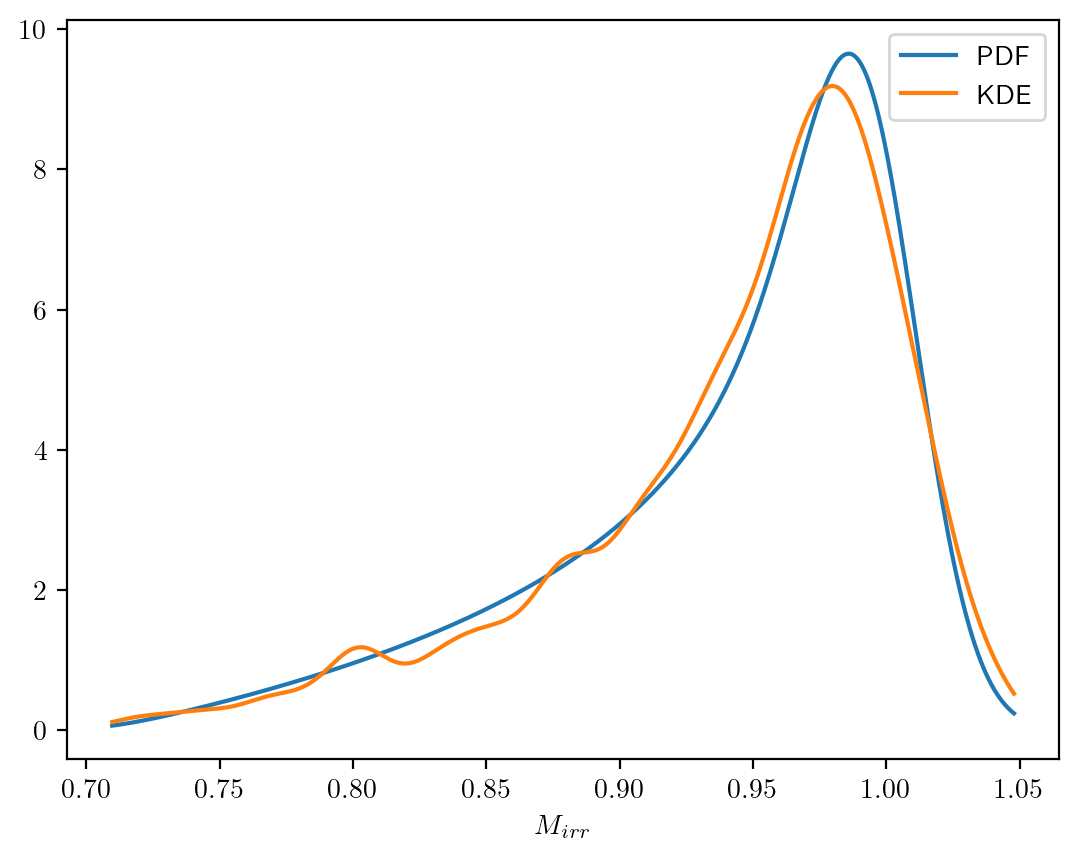

In [14]:
pdf_M = [p_m(mm) for mm in Mgrid]
plt.plot(Mgrid, pdf_M, label = 'PDF')
plt.plot(Mgrid, kde_pdf, label = 'KDE')
plt.xlabel(r'$M_{irr}$')
plt.legend()